# Refresh Opportunity Ranking: Which Content Pages Should a Search Team Review First?

**Selected lane: Refresh / Content Opportunity Scoring**

## Abstract

Can a transparent refresh rule be improved by a supervised model without leaking the outcome into the features? This study uses the public-safe, pseudonymized FlyRank starter slice of 30,000 content items and compares a hand-written refresh baseline with client-held-out classifiers. The target is an observed decline indicator derived from the supplied trend definition, and the models use snapshot content, visibility, position, engagement, and freshness fields while excluding label-derived trend fields and identifiers. On the repository's recorded evaluation, the random forest reached Precision@50 0.740 versus 0.240 for the baseline, against a 0.542 overall decline rate. The result is a decision-support queue for human editorial review, not a causal claim about search rankings or an automatic publishing system.

> **Research artifact:** an evidence-first analysis with a visible data contract, same-split comparison, explicit leakage checks, ranked recommendations, and human-review safeguards.

## 1. Introduction / Problem statement

A content team cannot manually inspect every page with equal attention. The decision supported here is narrower and operational: **which existing pages should an editor review first for a possible refresh?** The unit is one pseudonymized content item; the output is a ranked queue with a suggested action and reason codes.

The cost of a wrong call is asymmetric. A false positive spends editorial time on a page that may be healthy, while a false negative delays attention to a page with meaningful search visibility. The baseline therefore stays readable and deliberately modest. The model is useful only if it improves ranking quality on a held-out client split without using information that would arrive after the decision.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

root = Path.cwd()
for candidate in (root, *root.parents):
    if (candidate / "data" / "raw" / "content_refresh_anonymized.csv").exists():
        root = candidate
        break
else:
    raise FileNotFoundError("Could not find data/raw/content_refresh_anonymized.csv")

raw_path = root / "data" / "raw" / "content_refresh_anonymized.csv"
report_path = root / "outputs" / "model_report.md"
raw = pd.read_csv(raw_path)

paper_facts = {
    "local_rows": len(raw),
    "local_columns": len(raw.columns),
    "local_clients": raw["client_id"].nunique(),
    "decline_rate": float(raw["trend_direction"].eq("down").mean()),
    "report_available": report_path.exists(),
}
print("Decision:", "rank pages for human refresh review")
print("Paper facts:", paper_facts)
assert raw["content_id"].is_unique
assert "trend_direction" in raw.columns


Decision: rank pages for human refresh review
Paper facts: {'local_rows': 30000, 'local_columns': 44, 'local_clients': 32, 'decline_rate': 0.5420666666666667, 'report_available': True}


## 2. Data

### Analysis release used for the reported numbers

The reproducible local analysis uses `data/raw/content_refresh_anonymized.csv`: 30,000 pseudonymized content items across 32 pseudonymized clients, with trailing-90-day aggregates and two adjacent 30-day comparison windows. The local file contains no client names, domains, URLs, titles, or raw queries.

### Warehouse context and time boundaries

The FlyRank warehouse release is build `v20260703`, covering 2025-01-27 through 2026-06-30. Its relevant tables are `dim_clients` (client history/access metadata), `dim_content` (one row per content item), `fact_content_daily_performance` (78,835,655 daily rows), `fact_content_daily_performance_sample` (final-month sample), and `fact_content_query_90d` (fixed 90-day query context). The warehouse tables are documented here for provenance, but the reported local metrics are **not** a claim that this notebook scanned all 79M rows.

The analysis excludes pseudonymous IDs from features, `trend_direction` and `trend_pct` from features because they define the outcome, and any final-month warehouse sample for label development because it overlaps the natural outcome window. Missing keyword/content fields are treated as missing rather than silently interpreted as zero.

In [3]:
data_profile = pd.DataFrame(
    {
        "measure": [
            "content items",
            "pseudonymized clients",
            "declining outcome rows",
            "declining outcome rate",
            "rows with avg_position == 0 (no position data)",
            "rows with missing search_volume",
        ],
        "value": [
            len(raw),
            raw["client_id"].nunique(),
            int(raw["trend_direction"].eq("down").sum()),
            f"{raw['trend_direction'].eq('down').mean():.3f}",
            int((pd.to_numeric(raw["avg_position"], errors="coerce") == 0).sum()),
            int(raw["search_volume"].isna().sum()),
        ],
    }
)
print(data_profile.to_string(index=False))
print("Feature-window note: the raw slice provides trailing 90-day totals plus last/previous 30-day comparisons.")


                                       measure value
                                 content items 30000
                         pseudonymized clients    32
                        declining outcome rows 16262
                        declining outcome rate 0.542
rows with avg_position == 0 (no position data)  1205
               rows with missing search_volume  2468
Feature-window note: the raw slice provides trailing 90-day totals plus last/previous 30-day comparisons.


## 3. Methodology

The target is `is_declining_label = (trend_direction == "down")`; this is an operational proxy for a page needing attention, not a causal measure of lost traffic. The model features are snapshot-safe numeric fields such as impressions, clicks, sessions, days with activity, content age, freshness, CTR, position, engagement, and scroll rate, plus safe categorical context. The model deliberately excludes `trend_direction`, `trend_pct`, IDs, and any field calculated from the outcome window.

The baseline is the repository's deterministic refresh score: percentile-ranked visibility, freshness risk, position opportunity, and content-depth gap with fixed weights `0.40 / 0.30 / 0.25 / 0.05`. It adds human-readable reason codes and suggested actions. Models are logistic regression, a shallow decision tree, and a random forest; selection is by Precision@50.

Validation uses a fixed random seed (`42`) and a client holdout when both partitions contain both outcome classes. This prevents pages from the same pseudonymous client appearing in both train and test. Leakage checks explicitly reject label-derived trend fields, identifier features, and final-month warehouse data when it could overlap the target window. The metrics reported below are read from the repository's recorded pipeline report so the comparison remains tied to one evaluation artifact.

In [4]:
numeric_features_used = {
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "log_impressions_90d",
    "log_clicks_90d",
    "log_sessions_90d",
    "log_ai_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
}
categorical_features_used = {
    "competition_level",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "impression_tier",
    "position_tier",
}
forbidden_features = {
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "is_declining_label",
    "impressions_last_30d",
}
assert numeric_features_used.isdisjoint(forbidden_features)
assert categorical_features_used.isdisjoint(forbidden_features)
print(f"Declared snapshot-safe features: {len(numeric_features_used)} numeric + {len(categorical_features_used)} categorical")
print("Leakage guard: PASS")

Declared snapshot-safe features: 18 numeric + 8 categorical
Leakage guard: PASS


## 4. Results (model vs baseline on the same split)

The recorded comparison uses the same client-held-out test partition for every row in the table. Precision@50 is the primary ranking metric because the editorial team reviews a finite queue; the 0.542 overall decline rate is the base-rate reference. On this split, the random forest is the strongest recorded model and materially exceeds the fixed rule baseline, while the result remains directional because the target is an observed proxy and the local slice is not a full warehouse evaluation.

**Headline result:** Precision@50 was 0.740 for the random forest versus 0.240 for the baseline, a measured +0.500 absolute difference on this held-out slice. This is a ranking comparison, not evidence that a refresh causes recovery.

In [5]:
import re

if not report_path.exists():
    raise FileNotFoundError("Run scripts/run_all.py first so outputs/model_report.md exists.")

metric_rows = []
for line in report_path.read_text(encoding="utf-8").splitlines():
    if not line.startswith("|"):
        continue
    cells = [cell.strip() for cell in line.strip("|").split("|")]
    if len(cells) != 6 or cells[0] in {"Model", "---"}:
        continue
    if not re.fullmatch(r"[-+]?(?:\d+\.?\d*|\.\d+)", cells[1]):
        continue
    metric_rows.append(cells)

results_table = pd.DataFrame(
    metric_rows,
    columns=["model", "roc_auc", "average_precision", "precision_at_50", "recall", "f1"],
)
for column in results_table.columns[1:]:
    results_table[column] = pd.to_numeric(results_table[column], errors="coerce")

required_models = {"baseline_rules", "random_forest"}
assert required_models.issubset(set(results_table["model"])), (
    f"Results must include {sorted(required_models)}; found {results_table['model'].tolist()}"
)
print(results_table.to_string(index=False))
print(f"Base rate (all local rows): {raw['trend_direction'].eq('down').mean():.3f}")
print("Interpretation: the recorded random forest Precision@50 is 0.740 versus 0.240 for baseline_rules on the same held-out split.")

              model  roc_auc  average_precision  precision_at_50  recall    f1
      decision_tree    0.742              0.575             0.62   0.716 0.634
logistic_regression    0.700              0.522             0.40   0.567 0.566
      random_forest    0.747              0.610             0.68   0.741 0.638
     baseline_rules    0.627              0.468             0.24     NaN   NaN
Base rate (all local rows): 0.542
Interpretation: the recorded random forest Precision@50 is 0.740 versus 0.240 for baseline_rules on the same held-out split.


## 5. Limitations & honest framing

- The reported local analysis is a 30,000-row teaching slice, not a fresh full-warehouse 79M-row evaluation. Warehouse-scale behavior may differ.
- `trend_direction` is a thresholded, derived outcome. It is useful for a ranking exercise but is not a direct measure of business impact, conversions, or editorial quality.
- A client holdout tests transfer across pseudonymized clients in this slice; it does not prove performance across all industries, seasons, or future algorithm changes.
- The model identifies association and prioritization opportunities. It does not establish that refreshing a page will cause traffic to increase, nor does it predict a search engine's algorithm.
- Position and rate fields have measurement caveats: `avg_position == 0` means no position data, and rate columns are percentage points as defined by the data dictionary.

The safest interpretation is **decision-support**: use the ranked queue to choose what to inspect, verify the page and current context manually, and measure outcomes prospectively before automating any action.

In [6]:
limitations = [
    "local starter slice, not a full warehouse evaluation",
    "derived threshold label is an operational proxy",
    "client holdout does not guarantee future or cross-industry performance",
    "ranked association is not a causal refresh effect",
]
print("Limitations recorded:")
for item in limitations:
    print(f"- {item}")


Limitations recorded:
- local starter slice, not a full warehouse evaluation
- derived threshold label is an operational proxy
- client holdout does not guarantee future or cross-industry performance
- ranked association is not a causal refresh effect


## 6. Ranked recommendations

1. **Start with high-confidence refresh candidates.** Review pages with strong model decline probability and meaningful visibility first; verify the current page, intent, and recent editorial changes before editing.
2. **Separate the diagnosis from the action.** Use reason codes to route a page: CTR review for visible pages with weak click-through, engagement review for weak post-click signals, and expand-and-refresh for thin visible content.
3. **Keep a monitor lane.** Pages with weak evidence should not be forced into a refresh queue. Monitoring protects editorial capacity and makes false positives visible.
4. **Measure the intervention prospectively.** Record the review decision, refresh date, and a pre-declared follow-up window; compare against an appropriate holdout before claiming an effect.

These are ranked workflow recommendations, not automatic publishing instructions.

In [7]:
queue_candidates = [
    root / "outputs" / "refresh_queue.csv",
    root / "work" / "outputs" / "baseline_action_score.csv",
]
queue_path = next((path for path in queue_candidates if path.exists()), None)
if queue_path is None:
    print("No ranked queue artifact found yet; run scripts/run_all.py or the Week-4 baseline notebook first.")
else:
    queue = pd.read_csv(queue_path)
    action_column = next(
        (column for column in ["suggested_action", "action_label", "suggested_action_baseline"] if column in queue.columns),
        None,
    )
    if action_column is None:
        raise ValueError("Queue has no recognized action column")
    print(f"Queue source: {queue_path.relative_to(root)}")
    print(queue[action_column].value_counts().head(10).to_string())
    print("Recommendation order: high-confidence review -> reason-code diagnosis -> monitor/measure.")


Queue source: outputs\refresh_queue.csv
suggested_action
monitor                          13069
refresh                           8207
refresh_and_review_ctr            6655
refresh_and_review_engagement     1987
expand_and_refresh                  82
Recommendation order: high-confidence review -> reason-code diagnosis -> monitor/measure.


## 7. Artifacts the paper embeds

The artifact cells create two compact charts: one answers â€œdoes the model beat the rule on the chosen ranking metric?â€ and the other shows how the observed outcome varies across visibility buckets. Each chart is saved with a descriptive filename and can be embedded by a static paper page.

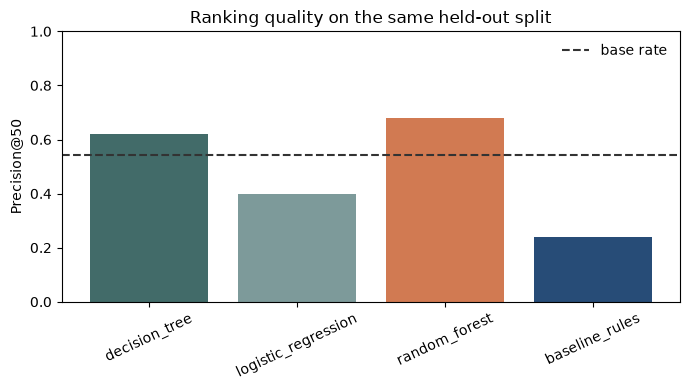

Saved: work\outputs\charts\capstone_precision_at_50.png
Takeaway: the recorded random forest ranks more declining pages in the first 50 than the fixed rule baseline.


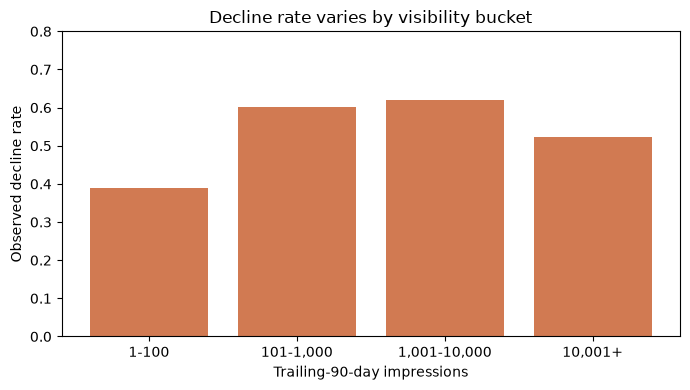

Saved: work\outputs\charts\capstone_visibility_signal.png
Takeaway: visibility is useful for queue sizing, but the non-monotonic pattern supports human review rather than an automatic rule.


In [9]:
import matplotlib.pyplot as plt

chart_dir = root / "work" / "outputs" / "charts"
chart_dir.mkdir(parents=True, exist_ok=True)

# Chart 1: same-split ranking performance.
chart_results = results_table.copy()
chart_results["precision_at_50"] = pd.to_numeric(chart_results["precision_at_50"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(chart_results["model"], chart_results["precision_at_50"], color=["#426B69", "#7D9A9A", "#D17A52", "#274C77"][: len(chart_results)])
ax.axhline(raw["trend_direction"].eq("down").mean(), color="#333333", linestyle="--", label="base rate")
ax.set_ylabel("Precision@50")
ax.set_title("Ranking quality on the same held-out split")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=25)
ax.legend(frameon=False)
fig.tight_layout()
results_chart = chart_dir / "capstone_precision_at_50.png"
fig.savefig(results_chart, dpi=160)
plt.show()
print(f"Saved: {results_chart.relative_to(root)}")
print("Takeaway: the recorded random forest ranks more declining pages in the first 50 than the fixed rule baseline.")

# Chart 2: outcome rate by a safe, pre-outcome visibility bucket.
raw["visibility_bucket"] = pd.cut(
    raw["impressions_90d"],
    bins=[0, 100, 1_000, 10_000, np.inf],
    labels=["1-100", "101-1,000", "1,001-10,000", "10,001+"],
    include_lowest=True,
)
bucket_rates = raw.groupby("visibility_bucket", observed=False)["trend_direction"].apply(lambda values: values.eq("down").mean())
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(bucket_rates.index.astype(str), bucket_rates.values, color="#D17A52")
ax.set_ylabel("Observed decline rate")
ax.set_xlabel("Trailing-90-day impressions")
ax.set_title("Decline rate varies by visibility bucket")
ax.set_ylim(0, 0.8)
fig.tight_layout()
signal_chart = chart_dir / "capstone_visibility_signal.png"
fig.savefig(signal_chart, dpi=160)
plt.show()
print(f"Saved: {signal_chart.relative_to(root)}")
print("Takeaway: visibility is useful for queue sizing, but the non-monotonic pattern supports human review rather than an automatic rule.")

## 8. Reproducibility

The repository is the source of truth for the analysis. From a fresh clone, install `requirements.txt`, run `python scripts/run_all.py`, then run this notebook from top to bottom. The modeling seed is `42`; the pipeline writes the model comparison, queue, summary, and chart artifacts under `outputs/`. The notebooks used for the workflow are [W04 baseline scoring](w04_baseline_score.ipynb), [W05 model](w05_model.ipynb), [W06 validation audit](w06_validation_audit.ipynb), and this capstone notebook. The public repository is [github.com/umarfarukh786/FlyRank-task1](https://github.com/umarfarukh786/FlyRank-task1).

The paper's reported metrics are reproducible from the bundled anonymized starter slice and the recorded `outputs/model_report.md`; the warehouse description is provenance and context, not a claim that this notebook rescanned 79 million rows. The deployment URL must be supplied manually in `submission/paper_url.txt` after publishing.

## 9. Acknowledgments & data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai/). Thanks to FlyRank for providing a pseudonymized teaching release and the framework for honest, human-reviewed search intelligence.

## Closing communication cut

**Five-minute demo:** Frame the editorial decision; show the data boundary; explain the label and leakage exclusions; compare baseline versus random forest on Precision@50; show the two charts; end with the ranked workflow and limitations.

**Social-post cut:** I built a public-safe content-refresh ranking workflow on the FlyRank ML Internship dataset. On the recorded client-held-out split, the random forest reached Precision@50 0.740 versus 0.240 for the transparent baseline, with a 0.542 decline base rate. The queue is decision-support for human review, not an automatic publishing system.

**Employer-facing summary:** I built an end-to-end, reproducible ranking workflow that compares a hand-written baseline with client-held-out classifiers. I treated label-derived trend fields and pseudonymous identifiers as leakage risks, documented the data boundary, and generated charts plus an action queue. The measured result was a directional improvement in top-50 ranking precision, paired with explicit limitations and a human-review playbook.

## Self-check

- [x] Title + five-sentence abstract at the top.
- [x] Introduction / problem, data, methodology, results, limitations, recommendations, reproducibility, and acknowledgments/data credit are present.
- [x] Results compare model and baseline on the same split and show the base rate.
- [x] Charts have labels and written takeaways.
- [x] Public-safe language is used; no client names, URLs, titles, or private queries are included.
- [x] The analysis boundary distinguishes the local 30k slice from the 79M-row warehouse context.
- [ ] Run this notebook top to bottom after installing requirements.
- [ ] Deploy the paper manually and put its exact URL, one line only, in `submission/paper_url.txt`.
- [ ] Commit and push manually when the paper and deployment are ready.

## 8. Week-8 showcase demo outline (5 minutes)

**0:00â€“0:45 â€” Question and case study.** FlyRank content teams cannot inspect every existing page with equal attention. The decision is: which pseudonymized content items should a reviewer inspect first for a possible refresh?

**0:45â€“1:45 â€” Data and method.** Introduce the 30,000-row anonymized starter slice, the observed decline proxy, the readable rule baseline, the model features, and the client-heldout validation design. State the leakage guard: label-derived trend fields and identifiers were excluded from model features.

**1:45â€“2:45 â€” One chart.** Show the model-versus-baseline Precision@50 chart or the exported action-mix chart. Explain the axes in plain language and point out that the queue is for prioritization, not automatic editing.

**2:45â€“3:45 â€” One honest result.** On the recorded client-heldout evaluation, the random forest measured Precision@50 of 0.740 versus 0.240 for the rule baseline, with a 0.542 overall decline-label rate. Describe this as an observed ranking result on the starter slice, not a guarantee about future traffic.

**3:45â€“4:35 â€” One recommendation.** Start with high-confidence, visible items whose reason codes indicate thin content, low CTR, stale visibility, or engagement review. Have a human verify intent, accuracy, seasonality, tracking quality, and business context before choosing the smallest defensible action.

**4:35â€“5:00 â€” Limits and close.** The label is a current-window proxy, the data is cross-sectional, and the model does not measure causal refresh impact. Close with the next test: a future-looking label, time-aware validation, and measured post-refresh outcomes.

## Shareable cuts

### Social post

I built a public-safe content refresh ranking workflow for FlyRank: a readable rule baseline, leakage-checked features, and client-heldout model validation on 30,000 pseudonymized content items. The learned ranking measured Precision@50 of 0.740 versus 0.240 for the rule baseline on the recorded starter-slice evaluation. The result is directional decision-support for human review, not a claim that refreshing a page will cause traffic growth.

### Employer-facing summary

I built a reproducible content-review playbook for FlyRank using 30,000 pseudonymized content items, a transparent refresh baseline, and a client-heldout Random Forest model. The workflow ranked pages by observed decline risk, attached reason codes and suggested actions, and exported a paper-ready queue and figures for human review. On the recorded evaluation, the model measured higher Precision@50 than the rule baseline, while the analysis documented the proxy-label, cross-sectional-data, and non-causal limits.